# Apriori vs Word2Vec Model Comparison

This notebook compares the performance of Apriori and Word2Vec models for detecting complementary products in market basket analysis. The comparison includes:

- Execution time and memory usage
- Coverage and diversity metrics
- Clustering quality 
- Visualization of key metrics

The `ModelEvaluator` class handles the evaluation process, including model training, metric calculation, and visualization.

## Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import time
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import TimeSeriesSplit
from scipy import stats
from collections import Counter
from gensim.models import Word2Vec
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

## ModelEvaluator Class Definition

In [2]:
class ModelEvaluator:
    """
    Enhanced class to evaluate and compare Apriori and Word2Vec models across multiple metrics,
    with improved statistical validation, parameter exploration, and realistic evaluation.
    """
    
    def __init__(self, data_path, excel_file, date_column='Date', min_item_count=5, random_seed=42):
        """
        Initialize with dataset path and enhanced parameters.
        
        Args:
            data_path (str): Path to the data directory
            excel_file (str): Name of the Excel file containing transaction data
            date_column (str): Name of the date column for temporal validation
            min_item_count (int): Minimum count threshold for items to include
            random_seed (int): Random seed for reproducibility
        """
        self.data_path = data_path
        self.excel_file = excel_file
        self.file_path = os.path.join(data_path, excel_file)
        self.date_column = date_column
        self.min_item_count = min_item_count
        self.random_seed = random_seed
        self.metrics = {
            'apriori': {},
            'word2vec': {}
        }
        
        # Load and preprocess dataset
        self._load_and_preprocess_data()
        
        # Initialize result dataframes
        self.apriori_rules = None
        self.word2vec_complementary = None
        self.apriori_models = {}
        self.word2vec_models = {}
        self.validation_results = {
            'apriori': [],
            'word2vec': []
        }
        
        np.random.seed(random_seed)
        print(f"Dataset loaded with {len(self.basket)} transactions and {len(self.unique_products)} unique products")
        
    def _load_and_preprocess_data(self):
        """
        Load and preprocess data with options for filtering rare items and handling imbalance.
        """
        # Load data
        self.data_excel = pd.read_excel(self.file_path)
        self.data_excel.dropna(subset=['Itemname'], inplace=True)
        
        # Convert date column to datetime if it exists
        if self.date_column in self.data_excel.columns:
            self.data_excel[self.date_column] = pd.to_datetime(self.data_excel[self.date_column])
            self.has_temporal_data = True
        else:
            self.has_temporal_data = False
            print("Warning: No date column found. Temporal validation will be disabled.")
        
        # Count item frequencies
        item_counts = Counter(self.data_excel['Itemname'])
        
        # Filter out rare items
        frequent_items = {item for item, count in item_counts.items() if count >= self.min_item_count}
        self.data_excel = self.data_excel[self.data_excel['Itemname'].isin(frequent_items)]
        
        # Create transaction baskets
        self.basket = self.data_excel.groupby('BillNo')['Itemname'].apply(list)
        self.transactions = self.basket.values.tolist()
        self.unique_products = sorted(list(frequent_items))
        
        # Prepare temporal data if available
        if self.has_temporal_data:
            self.temporal_transactions = self.data_excel.sort_values(self.date_column).groupby('BillNo').agg({
                'Itemname': list,
                self.date_column: 'min'  # Use transaction start time
            })
            # Create time-ordered transactions
            self.time_ordered_transactions = list(self.temporal_transactions['Itemname'])
            self.transaction_times = list(self.temporal_transactions[self.date_column])
    
    def get_parameter_grid(self, model_type):
        """
        Get parameter grid for model optimization.
        
        Args:
            model_type (str): 'apriori' or 'word2vec'
            
        Returns:
            list: List of parameter dictionaries
        """
        if model_type == 'apriori':
            # Parameters for Apriori
            min_support_values = [0.005, 0.01, 0.02]
            min_confidence_values = [0.05, 0.1, 0.2]
            min_lift_values = [1.0, 1.2, 1.5]
            
            param_grid = []
            for min_support in min_support_values:
                for min_confidence in min_confidence_values:
                    for min_lift in min_lift_values:
                        param_grid.append({
                            'min_support': min_support,
                            'min_confidence': min_confidence,
                            'min_lift': min_lift
                        })
            
        elif model_type == 'word2vec':
            # Parameters for Word2Vec
            vector_size_values = [50, 100, 150]
            window_values = [3, 5, 7]
            min_count_values = [1, 2, 5]
            
            param_grid = []
            for vector_size in vector_size_values:
                for window in window_values:
                    for min_count in min_count_values:
                        param_grid.append({
                            'vector_size': vector_size,
                            'window': window,
                            'min_count': min_count
                        })
        else:
            raise ValueError("model_type must be 'apriori' or 'word2vec'")
            
        return param_grid
    
    def run_apriori(self, min_support=0.01, min_confidence=0.05, min_lift=1.2, n_runs=3):
        """
        Run Apriori algorithm with multiple runs for statistical validation.
        
        Args:
            min_support (float): Minimum support threshold
            min_confidence (float): Minimum confidence threshold
            min_lift (float): Minimum lift threshold
            n_runs (int): Number of runs for statistical validation
            
        Returns:
            dict: Performance metrics for Apriori
        """
        print("Running Apriori algorithm...")
        
        # Store metrics from multiple runs
        run_metrics = []
        
        for run in range(n_runs):
            print(f"Run {run+1}/{n_runs}")
            
            # Start the process and memory measurement
            process = psutil.Process(os.getpid())
            start_memory = process.memory_info().rss / 1024 / 1024  # MB
            start_time = time.time()
            
            # Convert transactions to binary format
            te = TransactionEncoder()
            te_ary = te.fit(self.transactions).transform(self.transactions)
            basket_encoded = pd.DataFrame(te_ary, columns=te.columns_)
            
            # Generate frequent itemsets
            frequent_itemsets = apriori(basket_encoded, min_support=min_support, use_colnames=True)
            
            # Generate association rules
            rules = association_rules(frequent_itemsets, metric="lift", min_threshold=min_lift)
            rules = rules[rules['confidence'] >= min_confidence]
            
            # Add antecedent length column
            rules["antecedent_len"] = rules["antecedents"].apply(lambda x: len(x))
            
            # End time and memory measurement
            end_time = time.time()
            end_memory = process.memory_info().rss / 1024 / 1024  # MB
            
            # Calculate standard metrics
            standard_metrics = self._calculate_standard_metrics(rules, 'apriori')
            
            # Store this run's metrics
            run_result = {
                'execution_time': end_time - start_time,
                'memory_usage': end_memory - start_memory,
                'num_rules': len(rules),
                **standard_metrics
            }
            run_metrics.append(run_result)
        
        # Calculate average metrics across runs
        avg_metrics = {}
        for key in run_metrics[0].keys():
            values = [run[key] for run in run_metrics]
            avg_metrics[key] = np.mean(values)
            # Also calculate confidence intervals
            ci = stats.t.interval(0.95, len(values)-1, loc=np.mean(values), scale=stats.sem(values))
            avg_metrics[f"{key}_ci_low"] = ci[0]
            avg_metrics[f"{key}_ci_high"] = ci[1]
        
        # Store the last run's rules for further analysis
        self.apriori_rules = rules
        
        # Store in class-wide metrics
        self.metrics['apriori'] = avg_metrics
        
        print(f"Apriori completed with an average of {avg_metrics['num_rules']:.0f} rules generated")
        print(f"Coverage: {avg_metrics['coverage']:.4f} (95% CI: {avg_metrics['coverage_ci_low']:.4f}-{avg_metrics['coverage_ci_high']:.4f})")
        print(f"Diversity: {avg_metrics['diversity']:.4f} (95% CI: {avg_metrics['diversity_ci_low']:.4f}-{avg_metrics['diversity_ci_high']:.4f})")
        
        return avg_metrics
    
    def run_word2vec(self, vector_size=100, window=5, min_count=2, topn=10, n_runs=3):
        """
        Run Word2Vec model with multiple runs for statistical validation.
        
        Args:
            vector_size (int): Dimensionality of word vectors
            window (int): Context window size
            min_count (int): Minimum word frequency
            topn (int): Number of top complementary products to generate
            n_runs (int): Number of runs for statistical validation
            
        Returns:
            dict: Performance metrics for Word2Vec
        """
        print("Running Word2Vec model...")
        
        # Store metrics from multiple runs
        run_metrics = []
        
        for run in range(n_runs):
            print(f"Run {run+1}/{n_runs}")
            np.random.seed(self.random_seed + run)  # Different seed for each run
            
            # Start the process and memory measurement
            process = psutil.Process(os.getpid())
            start_memory = process.memory_info().rss / 1024 / 1024  # MB
            start_time = time.time()
            
            # Train Word2Vec model
            model = Word2Vec(
                sentences=self.transactions,
                vector_size=vector_size,
                window=window,
                sg=1,  # Skip-gram model
                negative=5,  # Negative sampling
                min_count=min_count,
                workers=4,
                epochs=10,
                seed=self.random_seed + run
            )
            
            # Generate complementary products
            recommendations = self._generate_word2vec_recommendations(model, topn)
            
            # End time and memory measurement
            end_time = time.time()
            end_memory = process.memory_info().rss / 1024 / 1024  # MB
            
            # Calculate standard metrics
            standard_metrics = self._calculate_standard_metrics(recommendations, 'word2vec')
            
            # Store this run's metrics
            run_result = {
                'execution_time': end_time - start_time,
                'memory_usage': end_memory - start_memory,
                'num_recommendations': len(recommendations),
                **standard_metrics
            }
            run_metrics.append(run_result)
            
            # Store model from last run
            if run == n_runs - 1:
                self.word2vec_model = model
                self.word2vec_complementary = recommendations
        
        # Calculate average metrics across runs
        avg_metrics = {}
        for key in run_metrics[0].keys():
            values = [run[key] for run in run_metrics]
            avg_metrics[key] = np.mean(values)
            # Also calculate confidence intervals
            ci = stats.t.interval(0.95, len(values)-1, loc=np.mean(values), scale=stats.sem(values))
            avg_metrics[f"{key}_ci_low"] = ci[0]
            avg_metrics[f"{key}_ci_high"] = ci[1]
        
        # Store in class-wide metrics
        self.metrics['word2vec'] = avg_metrics
        
        print(f"Word2Vec completed with an average of {avg_metrics['num_recommendations']:.0f} recommendations generated")
        print(f"Coverage: {avg_metrics['coverage']:.4f} (95% CI: {avg_metrics['coverage_ci_low']:.4f}-{avg_metrics['coverage_ci_high']:.4f})")
        print(f"Diversity: {avg_metrics['diversity']:.4f} (95% CI: {avg_metrics['diversity_ci_low']:.4f}-{avg_metrics['diversity_ci_high']:.4f})")
        
        return avg_metrics
    
    def _generate_word2vec_recommendations(self, model, topn=10):
        """
        Generate recommendations using Word2Vec model.
        
        Args:
            model (Word2Vec): Trained Word2Vec model
            topn (int): Number of recommendations per product
            
        Returns:
            DataFrame: Product recommendations
        """
        comprehensive_results = []
        
        # Dictionary to store model vocabulary for fast lookup
        model_vocab = set(model.wv.index_to_key)
        
        for product in self.unique_products:
            if product in model_vocab:
                try:
                    similar_products = model.wv.most_similar(product, topn=topn)
                    
                    complementary_list = [
                        {
                            'Original Product': product,
                            'Complementary Product': comp_product,
                            'Similarity Score': similarity,
                            'Rank': rank + 1
                        }
                        for rank, (comp_product, similarity) in enumerate(similar_products)
                    ]
                    
                    comprehensive_results.extend(complementary_list)
                except KeyError:
                    pass
        
        return pd.DataFrame(comprehensive_results)
    
    def _calculate_standard_metrics(self, data, model_type):
        """
        Calculate standardized metrics for both models to ensure proper comparison.
        
        Args:
            data: Model output (rules or recommendations)
            model_type (str): 'apriori' or 'word2vec'
            
        Returns:
            dict: Standardized metrics
        """
        if model_type == 'apriori':
            # Coverage: Proportion of unique products covered
            unique_antecedents = set()
            unique_consequents = set()
            
            for _, row in data.iterrows():
                antecedents = set(row['antecedents'])
                consequents = set(row['consequents'])
                
                unique_antecedents.update(antecedents)
                unique_consequents.update(consequents)
            
            unique_items = unique_antecedents.union(unique_consequents)
            coverage = len(unique_items) / len(self.unique_products)
            
            # Diversity: Normalize to [0,1] for comparison with Word2Vec
            if len(data) > 0:
                # Count unique (antecedent, consequent) pairs
                unique_pairs = data.apply(lambda row: (frozenset(row['antecedents']), 
                                                    frozenset(row['consequents'])), axis=1).nunique()
                # Diversity = unique pairs / total products
                diversity = unique_pairs / len(self.unique_products)
            else:
                diversity = 0
            
            # Calculate recommendation strength (using lift)
            if len(data) > 0:
                avg_lift = data['lift'].mean()
                max_lift = data['lift'].max()
            else:
                avg_lift = 0
                max_lift = 0
                
        elif model_type == 'word2vec':
            # Coverage: Proportion of products with recommendations
            products_with_embeddings = data['Original Product'].nunique()
            coverage = products_with_embeddings / len(self.unique_products)
            
            # Diversity: Normalize to [0,1] for comparison with Apriori
            if len(data) > 0:
                # Count unique (original, complementary) pairs
                unique_pairs = data.apply(lambda row: (row['Original Product'], 
                                                    row['Complementary Product']), axis=1).nunique()
                # Diversity = unique pairs / total products
                diversity = unique_pairs / len(self.unique_products)
            else:
                diversity = 0
            
            # Calculate recommendation strength (using similarity)
            if len(data) > 0:
                avg_lift = data['Similarity Score'].mean()  # Using similarity as lift equivalent
                max_lift = data['Similarity Score'].max()
            else:
                avg_lift = 0
                max_lift = 0
                
        else:
            raise ValueError("model_type must be 'apriori' or 'word2vec'")
        
        # Return standardized metrics
        return {
            'coverage': coverage,
            'diversity': diversity,
            'avg_strength': avg_lift,
            'max_strength': max_lift
        }
    
    def perform_temporal_validation(self, n_splits=3):
        """
        Perform temporal validation to simulate real-world recommendation scenarios.
        
        Args:
            n_splits (int): Number of time-based validation splits
            
        Returns:
            dict: Temporal validation metrics
        """
        if not self.has_temporal_data:
            print("Temporal validation requires a date column. Skipping.")
            return None
        
        print(f"Performing temporal validation with {n_splits} time splits...")
        
        # Use TimeSeriesSplit for temporal validation
        tscv = TimeSeriesSplit(n_splits=n_splits)
        
        # Create time-ordered transactions for splitting
        time_sorted_data = pd.DataFrame({
            'transactions': self.time_ordered_transactions,
            'time': self.transaction_times
        }).reset_index(drop=True)
        
        temporal_results = {
            'apriori': [],
            'word2vec': []
        }
        
        # Perform validation across time splits
        for train_idx, test_idx in tscv.split(time_sorted_data):
            train_transactions = time_sorted_data.iloc[train_idx]['transactions'].tolist()
            test_transactions = time_sorted_data.iloc[test_idx]['transactions'].tolist()
            
            # Flatten test transactions for validation
            test_products = set([item for sublist in test_transactions for item in sublist])
            
            # Run Apriori on training data
            train_encoded = TransactionEncoder().fit(train_transactions).transform(train_transactions)
            train_df = pd.DataFrame(train_encoded)
            
            frequent_itemsets = apriori(train_df, min_support=0.01, use_colnames=True)
            apriori_rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)
            apriori_rules = apriori_rules[apriori_rules['confidence'] >= 0.05]
            
            # Train Word2Vec on training data
            word2vec_model = Word2Vec(
                sentences=train_transactions,
                vector_size=100,
                window=5,
                min_count=2,
                workers=4,
                epochs=10,
                seed=self.random_seed
            )
            
            # Validate on test data
            apriori_score = self._validate_recommendations(apriori_rules, test_products, 'apriori')
            word2vec_score = self._validate_recommendations(word2vec_model, test_products, 'word2vec')
            
            temporal_results['apriori'].append(apriori_score)
            temporal_results['word2vec'].append(word2vec_score)
        
        # Calculate average metrics across splits
        for model in ['apriori', 'word2vec']:
            avg_results = {}
            for key in temporal_results[model][0].keys():
                values = [split[key] for split in temporal_results[model]]
                avg_results[key] = np.mean(values)
                # Calculate confidence intervals
                if len(values) > 1:
                    ci = stats.t.interval(0.95, len(values)-1, loc=np.mean(values), scale=stats.sem(values))
                    avg_results[f"{key}_ci_low"] = ci[0]
                    avg_results[f"{key}_ci_high"] = ci[1]
            
            self.validation_results[model] = avg_results
            print(f"\n{model.capitalize()} temporal validation results:")
            print(f"Precision: {avg_results['precision']:.4f}")
            print(f"Recall: {avg_results['recall']:.4f}")
            print(f"F1 Score: {avg_results['f1_score']:.4f}")
        
        return self.validation_results
    
    def _validate_recommendations(self, model_output, test_products, model_type):
        """
        Validate model recommendations against test data.
        
        Args:
            model_output: Rules (Apriori) or trained model (Word2Vec)
            test_products (set): Products in test set
            model_type (str): 'apriori' or 'word2vec'
            
        Returns:
            dict: Validation metrics
        """
        if model_type == 'apriori':
            # For Apriori, check if rules recommend items in test set
            hits = 0
            total = 0
            potential_hits = 0
            
            for _, rule in model_output.iterrows():
                antecedents = set(rule['antecedents'])
                consequents = set(rule['consequents'])
                
                # Check if antecedents are in test set
                if antecedents.issubset(test_products):
                    total += len(consequents)
                    # Check if consequents are in test set
                    hits += len(consequents.intersection(test_products))
                    potential_hits += len(consequents)
            
            precision = hits / potential_hits if potential_hits > 0 else 0
            recall = hits / len(test_products) if len(test_products) > 0 else 0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            
        elif model_type == 'word2vec':
            # For Word2Vec, generate recommendations for test products and check hits
            hits = 0
            total_recommendations = 0
            
            # Get model vocabulary
            model_vocab = set(model_output.wv.index_to_key)
            test_in_vocab = test_products.intersection(model_vocab)
            
            for product in test_in_vocab:
                try:
                    # Get top 5 similar products
                    similar_products = [p for p, _ in model_output.wv.most_similar(product, topn=5)]
                    total_recommendations += len(similar_products)
                    
                    # Check which recommendations are in test set
                    for rec in similar_products:
                        if rec in test_products:
                            hits += 1
                except KeyError:
                    continue
            
            precision = hits / total_recommendations if total_recommendations > 0 else 0
            recall = hits / len(test_products) if len(test_products) > 0 else 0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            
        else:
            raise ValueError("model_type must be 'apriori' or 'word2vec'")
        
        return {
            'precision': precision,
            'recall': recall,
            'f1_score': f1
        }
    
    def explore_parameters(self, model_type, n_best=3):
        """
        Explore different parameter settings and find optimal configurations.
        
        Args:
            model_type (str): 'apriori' or 'word2vec'
            n_best (int): Number of best configurations to return
            
        Returns:
            dict: Best parameter configurations and their metrics
        """
        print(f"Exploring parameters for {model_type}...")
        param_grid = self.get_parameter_grid(model_type)
        
        # Use a subset of data for faster parameter exploration
        sample_size = min(1000, len(self.transactions))
        sample_transactions = self.transactions[:sample_size]
        
        results = []
        
        for params in tqdm(param_grid, desc="Testing parameters"):
            if model_type == 'apriori':
                # Convert transactions to binary format
                te = TransactionEncoder()
                te_ary = te.fit(sample_transactions).transform(sample_transactions)
                basket_encoded = pd.DataFrame(te_ary, columns=te.columns_)
                
                # Generate frequent itemsets
                frequent_itemsets = apriori(
                    basket_encoded, 
                    min_support=params['min_support'], 
                    use_colnames=True
                )
                
                if len(frequent_itemsets) > 0:
                    # Generate association rules
                    rules = association_rules(
                        frequent_itemsets, 
                        metric="lift", 
                        min_threshold=params['min_lift']
                    )
                    rules = rules[rules['confidence'] >= params['min_confidence']]
                    
                    metrics = self._calculate_standard_metrics(rules, 'apriori')
                    metrics['num_rules'] = len(rules)
                else:
                    # No rules generated with these parameters
                    metrics = {
                        'coverage': 0,
                        'diversity': 0,
                        'avg_strength': 0,
                        'max_strength': 0,
                        'num_rules': 0
                    }
                
            elif model_type == 'word2vec':
                # Train Word2Vec model with these parameters
                model = Word2Vec(
                    sentences=sample_transactions,
                    vector_size=params['vector_size'],
                    window=params['window'],
                    sg=1,  # Skip-gram model
                    negative=5,
                    min_count=params['min_count'],
                    workers=4,
                    epochs=5,  # Fewer epochs for parameter search
                    seed=self.random_seed
                )
                
                recommendations = self._generate_word2vec_recommendations(model, topn=5)
                metrics = self._calculate_standard_metrics(recommendations, 'word2vec')
                metrics['num_recommendations'] = len(recommendations)
            
            # Calculate aggregate score for ranking
            # Weight coverage and diversity equally
            score = (metrics['coverage'] + metrics['diversity']) / 2
            
            results.append({
                'params': params,
                'score': score,
                **metrics
            })
        
        # Sort by score and get top n configurations
        results.sort(key=lambda x: x['score'], reverse=True)
        best_configs = results[:n_best]
        
        print(f"Best {n_best} parameter configurations for {model_type}:")
        for i, config in enumerate(best_configs):
            print(f"\nRank {i+1} (Score: {config['score']:.4f}):")
            print(f"Parameters: {config['params']}")
            print(f"Coverage: {config['coverage']:.4f}")
            print(f"Diversity: {config['diversity']:.4f}")
            
            if model_type == 'apriori':
                print(f"Number of rules: {config['num_rules']}")
            else:
                print(f"Number of recommendations: {config['num_recommendations']}")
        
        return best_configs
    
    def evaluate_cold_start(self, new_product_percentage=0.1):
        """
        Evaluate performance for cold-start products (new products without much transaction history).
        
        Args:
            new_product_percentage (float): Percentage of products to treat as "new"
            
        Returns:
            dict: Cold-start performance metrics
        """
        print("Evaluating cold-start performance...")
        
        # Randomly select products to treat as "new" (cold-start)
        np.random.seed(self.random_seed)
        num_cold_start = int(len(self.unique_products) * new_product_percentage)
        cold_start_products = set(np.random.choice(self.unique_products, num_cold_start, replace=False))
        
        # Create warm-start dataset by removing cold-start products
        warm_transactions = []
        for transaction in self.transactions:
            warm_transactions.append([item for item in transaction if item not in cold_start_products])
        
        # Train models on warm-start data
        # Apriori
        te = TransactionEncoder()
        te_ary = te.fit(warm_transactions).transform(warm_transactions)
        warm_df = pd.DataFrame(te_ary, columns=te.columns_)
        
        frequent_itemsets = apriori(warm_df, min_support=0.01, use_colnames=True)
        apriori_rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)
        apriori_rules = apriori_rules[apriori_rules['confidence'] >= 0.05]
        
        # Word2Vec
        word2vec_model = Word2Vec(
            sentences=warm_transactions,
            vector_size=100,
            window=5,
            min_count=2,
            workers=4,
            epochs=10,
            seed=self.random_seed
        )
        
        # Evaluate performance on cold-start products
        cold_start_results = {
            'apriori': {'coverage': 0, 'recommendations': 0},
            'word2vec': {'coverage': 0, 'recommendations': 0}
        }
        
        # For Apriori, check if cold-start products appear in consequents
        all_consequents = set()
        for _, rule in apriori_rules.iterrows():
            consequents = set(rule['consequents'])
            all_consequents.update(consequents)
        
        cold_start_covered_apriori = cold_start_products.intersection(all_consequents)
        cold_start_results['apriori']['coverage'] = len(cold_start_covered_apriori) / len(cold_start_products)
        cold_start_results['apriori']['recommendations'] = len(cold_start_covered_apriori)
        
        # For Word2Vec, check if cold-start products are in vocabulary
        word2vec_vocab = set(word2vec_model.wv.index_to_key)
        cold_start_covered_word2vec = cold_start_products.intersection(word2vec_vocab)
        cold_start_results['word2vec']['coverage'] = len(cold_start_covered_word2vec) / len(cold_start_products)
        cold_start_results['word2vec']['recommendations'] = len(cold_start_covered_word2vec)
        
        print("\nCold-start performance results:")
        print(f"Apriori coverage: {cold_start_results['apriori']['coverage']:.4f} ({cold_start_results['apriori']['recommendations']} of {len(cold_start_products)} products)")
        print(f"Word2Vec coverage: {cold_start_results['word2vec']['coverage']:.4f} ({cold_start_results['word2vec']['recommendations']} of {len(cold_start_products)} products)")
        
        return cold_start_results
    
    def analyze_clustering(self, n_clusters=5):
        """
        Perform separate clustering analysis for each model with proper interpretation.
        
        Args:
            n_clusters (int): Number of clusters to form
            
        Returns:
            dict: Clustering analysis results
        """
        print("Analyzing clustering patterns...")
        
        clustering_results = {
            'apriori': {},
            'word2vec': {}
        }
        
        # Ensure models have been run
        if self.apriori_rules is None or self.word2vec_complementary is None:
            print("Both models need to be run before clustering analysis")
            return None
        
        # Apriori clustering
        print("\nApriori Clustering Analysis:")
        apriori_features = []
        apriori_items = []
        
        for _, row in self.apriori_rules.iterrows():
            # Use lift, confidence, and support as features
            features = [row['lift'], row['confidence'], row['support']]
            apriori_features.append(features)
            
            # Keep track of the items for interpretation
            antecedent = tuple(sorted(row['antecedents']))
            consequent = tuple(sorted(row['consequents']))
            apriori_items.append((antecedent, consequent))
        
        if len(apriori_features) > n_clusters:
            # Apply KMeans clustering
            kmeans = KMeans(n_clusters=n_clusters, random_state=self.random_seed)
            apriori_labels = kmeans.fit_predict(apriori_features)
            
            # Calculate silhouette score
            if len(set(apriori_labels)) > 1:
                silhouette = silhouette_score(apriori_features, apriori_labels)
                clustering_results['apriori']['silhouette'] = silhouette
                print(f"Silhouette Score: {silhouette:.4f}")
            
            # Analyze clusters
            for cluster in range(n_clusters):
                cluster_indices = np.where(apriori_labels == cluster)[0]
                cluster_rules = [apriori_items[i] for i in cluster_indices]
                
                if len(cluster_rules) > 0:
                    # Calculate average metrics for this cluster
                    cluster_metrics = self.apriori_rules.iloc[cluster_indices]
                    avg_lift = cluster_metrics['lift'].mean()
                    avg_confidence = cluster_metrics['confidence'].mean()
                    avg_support = cluster_metrics['support'].mean()
                    
                    print(f"\nCluster {cluster + 1}: {len(cluster_rules)} rules")
                    print(f"Avg. Lift: {avg_lift:.4f}, Avg. Confidence: {avg_confidence:.4f}, Avg. Support: {avg_support:.4f}")
                    
                    # Sample rules from this cluster
                    sample_size = min(5, len(cluster_rules))
                    sample_indices = np.random.choice(cluster_indices, sample_size, replace=False)
                    
                    print("Sample rules:")
                    for idx in sample_indices:
                        antecedent, consequent = apriori_items[idx]
                        rule = self.apriori_rules.iloc[idx]
                        print(f"  {antecedent} -> {consequent} (Lift: {rule['lift']:.2f}, Conf: {rule['confidence']:.2f})")
            
            clustering_results['apriori']['clusters'] = n_clusters
            clustering_results['apriori']['items_per_cluster'] = [np.sum(apriori_labels == i) for i in range(n_clusters)]
        else:
            print("Not enough rules for clustering")
            clustering_results['apriori']['error'] = "Not enough rules for clustering"
        
        # Word2Vec clustering - Use product embeddings
        print("\nWord2Vec Clustering Analysis:")
        
        # Get unique products in recommendations
        unique_products = set(self.word2vec_complementary['Original Product'].unique())
        unique_products.update(self.word2vec_complementary['Complementary Product'].unique())
        
        # Get embeddings for these products
        product_embeddings = {}
        for product in unique_products:
            if product in self.word2vec_model.wv:
                product_embeddings[product] = self.word2vec_model.wv[product]
        
        if len(product_embeddings) > n_clusters:
            # Convert to feature matrix
            products = list(product_embeddings.keys())
            features = np.array([product_embeddings[p] for p in products])
            
            # Apply dimensionality reduction if needed (for visualization)
            if features.shape[1] > 10:
                # Use PCA or t-SNE for visualization later
                pass
            
            # Apply KMeans clustering
            kmeans = KMeans(n_clusters=n_clusters, random_state=self.random_seed)
            product_labels = kmeans.fit_predict(features)
            
            # Calculate silhouette score
            if len(set(product_labels)) > 1:
                silhouette = silhouette_score(features, product_labels)
                clustering_results['word2vec']['silhouette'] = silhouette
                print(f"Silhouette Score: {silhouette:.4f}")
            
            # Analyze clusters
            for cluster in range(n_clusters):
                cluster_indices = np.where(product_labels == cluster)[0]
                cluster_products = [products[i] for i in cluster_indices]
                
                if len(cluster_products) > 0:
                    print(f"\nCluster {cluster + 1}: {len(cluster_products)} products")
                    
                    # Find common recommendations within this cluster
                    cluster_recommendations = self.word2vec_complementary[
                        self.word2vec_complementary['Original Product'].isin(cluster_products)
                    ]
                    
                    # Get most common complementary products for this cluster
                    if len(cluster_recommendations) > 0:
                        complementary_counts = Counter(cluster_recommendations['Complementary Product'])
                        common_complementary = complementary_counts.most_common(5)
                        
                        print("Most commonly recommended with products in this cluster:")
                        for product, count in common_complementary:
                            print(f"  {product}: {count} recommendations")
                    
                    # Sample products from this cluster
                    sample_size = min(5, len(cluster_products))
                    sample_products = np.random.choice(cluster_products, sample_size, replace=False)
                    
                    print("Sample products in this cluster:")
                    for product in sample_products:
                        print(f"  {product}")
            
            clustering_results['word2vec']['clusters'] = n_clusters
            clustering_results['word2vec']['items_per_cluster'] = [np.sum(product_labels == i) for i in range(n_clusters)]
        else:
            print("Not enough products with embeddings for clustering")
            clustering_results['word2vec']['error'] = "Not enough products for clustering"
        
        return clustering_results
    
    def compare_models(self, include_validation=True, include_cold_start=True, include_clustering=False):
        """
        Compare performance metrics between Apriori and Word2Vec with statistical significance testing.
        
        Args:
            include_validation (bool): Include temporal validation results
            include_cold_start (bool): Include cold-start performance
            include_clustering (bool): Include clustering analysis
            
        Returns:
            DataFrame: Comparison of metrics
        """
        # Ensure both models have been run
        if not self.metrics['apriori'] or not self.metrics['word2vec']:
            print("Both models need to be run before comparison")
            return None
        
        # Basic metrics for comparison
        basic_metrics = [
            'Execution Time (s)',
            'Memory Usage (MB)',
            'Rules/Recommendations',
            'Coverage',
            'Coverage CI',
            'Diversity',
            'Diversity CI',
            'Average Strength'
        ]
        
        # Add validation metrics if available
        if include_validation and self.validation_results['apriori'] and self.validation_results['word2vec']:
            validation_metrics = [
                'Temporal Precision',
                'Temporal Recall',
                'Temporal F1 Score'
            ]
        else:
            validation_metrics = []
        
        # Add cold-start metrics if requested
        if include_cold_start:
            cold_start_results = self.evaluate_cold_start()
            cold_start_metrics = [
                'Cold-Start Coverage'
            ]
        else:
            cold_start_metrics = []
        
        # Add clustering metrics if requested
        if include_clustering:
            clustering_results = self.analyze_clustering()
            clustering_metrics = [
                'Clustering Silhouette'
            ]
        else:
            clustering_metrics = []
        
        # Combine all metrics
        metrics = basic_metrics + validation_metrics + cold_start_metrics + clustering_metrics
        
        # Create data for each metric
        data = []
        
        # Basic metrics
        data.append({
            'Metric': 'Execution Time (s)',
            'Apriori': self.metrics['apriori']['execution_time'],
            'Word2Vec': self.metrics['word2vec']['execution_time'],
            'Better': 'Word2Vec' if self.metrics['word2vec']['execution_time'] < self.metrics['apriori']['execution_time'] else 'Apriori'
        })
        
        data.append({
            'Metric': 'Memory Usage (MB)',
            'Apriori': self.metrics['apriori']['memory_usage'],
            'Word2Vec': self.metrics['word2vec']['memory_usage'],
            'Better': 'Word2Vec' if self.metrics['word2vec']['memory_usage'] < self.metrics['apriori']['memory_usage'] else 'Apriori'
        })
        
        data.append({
            'Metric': 'Rules/Recommendations',
            'Apriori': self.metrics['apriori'].get('num_rules', 0),
            'Word2Vec': self.metrics['word2vec'].get('num_recommendations', 0),
            'Better': 'N/A'  # More rules/recommendations isn't necessarily better
        })
        
        data.append({
            'Metric': 'Coverage',
            'Apriori': self.metrics['apriori']['coverage'],
            'Word2Vec': self.metrics['word2vec']['coverage'],
            'Better': 'Word2Vec' if self.metrics['word2vec']['coverage'] > self.metrics['apriori']['coverage'] else 'Apriori'
        })
        
        data.append({
            'Metric': 'Coverage CI',
            'Apriori': f"({self.metrics['apriori'].get('coverage_ci_low', 0):.4f}-{self.metrics['apriori'].get('coverage_ci_high', 0):.4f})",
            'Word2Vec': f"({self.metrics['word2vec'].get('coverage_ci_low', 0):.4f}-{self.metrics['word2vec'].get('coverage_ci_high', 0):.4f})",
            'Better': 'N/A'
        })
        
        data.append({
            'Metric': 'Diversity',
            'Apriori': self.metrics['apriori']['diversity'],
            'Word2Vec': self.metrics['word2vec']['diversity'],
            'Better': 'Word2Vec' if self.metrics['word2vec']['diversity'] > self.metrics['apriori']['diversity'] else 'Apriori'
        })
        
        data.append({
            'Metric': 'Diversity CI',
            'Apriori': f"({self.metrics['apriori'].get('diversity_ci_low', 0):.4f}-{self.metrics['apriori'].get('diversity_ci_high', 0):.4f})",
            'Word2Vec': f"({self.metrics['word2vec'].get('diversity_ci_low', 0):.4f}-{self.metrics['word2vec'].get('diversity_ci_high', 0):.4f})",
            'Better': 'N/A'
        })
        
        data.append({
            'Metric': 'Average Strength',
            'Apriori': self.metrics['apriori'].get('avg_strength', 0),
            'Word2Vec': self.metrics['word2vec'].get('avg_strength', 0),
            'Better': 'N/A'  # Different scales, not directly comparable
        })
        
        # Add validation metrics if available
        if include_validation and self.validation_results['apriori'] and self.validation_results['word2vec']:
            for metric in ['precision', 'recall', 'f1_score']:
                data.append({
                    'Metric': f"Temporal {metric.capitalize()}",
                    'Apriori': self.validation_results['apriori'][metric],
                    'Word2Vec': self.validation_results['word2vec'][metric],
                    'Better': 'Word2Vec' if self.validation_results['word2vec'][metric] > self.validation_results['apriori'][metric] else 'Apriori'
                })
        
        # Add cold-start metrics if requested
        if include_cold_start:
            data.append({
                'Metric': 'Cold-Start Coverage',
                'Apriori': cold_start_results['apriori']['coverage'],
                'Word2Vec': cold_start_results['word2vec']['coverage'],
                'Better': 'Word2Vec' if cold_start_results['word2vec']['coverage'] > cold_start_results['apriori']['coverage'] else 'Apriori'
            })
        
        # Add clustering metrics if requested
        if include_clustering:
            data.append({
                'Metric': 'Clustering Silhouette',
                'Apriori': clustering_results['apriori'].get('silhouette', 0),
                'Word2Vec': clustering_results['word2vec'].get('silhouette', 0),
                'Better': 'Apriori' if clustering_results['apriori'].get('silhouette', 0) > clustering_results['word2vec'].get('silhouette', 0) else 'Word2Vec'
            })
        
        # Create DataFrame and return
        comparison_df = pd.DataFrame(data)
        
        # Statistical significance testing for key metrics
        print("\nStatistical Significance Testing (95% confidence):")
        for metric in ['coverage', 'diversity']:
            apriori_ci_low = self.metrics['apriori'].get(f'{metric}_ci_low', 0)
            apriori_ci_high = self.metrics['apriori'].get(f'{metric}_ci_high', 0)
            word2vec_ci_low = self.metrics['word2vec'].get(f'{metric}_ci_low', 0)
            word2vec_ci_high = self.metrics['word2vec'].get(f'{metric}_ci_high', 0)
            
            # Check if confidence intervals overlap
            if word2vec_ci_high < apriori_ci_low or apriori_ci_high < word2vec_ci_low:
                significant = "YES"
            else:
                significant = "NO"
            
            print(f"{metric.capitalize()}: Significant difference: {significant}")
            print(f"  Apriori: {self.metrics['apriori'][metric]:.4f} ({apriori_ci_low:.4f}-{apriori_ci_high:.4f})")
            print(f"  Word2Vec: {self.metrics['word2vec'][metric]:.4f} ({word2vec_ci_low:.4f}-{word2vec_ci_high:.4f})")
        
        return comparison_df
    
    def visualize_comparison(self, save_path=None, include_ci=True, include_validation=True):
        """
        Create enhanced visualizations for model comparison.
        
        Args:
            save_path (str, optional): Path to save the visualization
            include_ci (bool): Include confidence intervals
            include_validation (bool): Include validation metrics
        """
        # Set up subplots
        num_plots = 4 + (3 if include_validation else 0)
        cols = 2
        rows = (num_plots + 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
        axes = axes.flatten()
        
        # Plot basic metrics
        basic_metrics = [
            ('Execution Time (s)', 'execution_time', 'lower'),
            ('Memory Usage (MB)', 'memory_usage', 'lower'),
            ('Coverage', 'coverage', 'higher'),
            ('Diversity', 'diversity', 'higher')
        ]
        
        for i, (title, metric, better) in enumerate(basic_metrics):
            ax = axes[i]
            
            # Get values
            apriori_value = self.metrics['apriori'][metric]
            word2vec_value = self.metrics['word2vec'][metric]
            
            # Plot bars
            bars = ax.bar(['Apriori', 'Word2Vec'], [apriori_value, word2vec_value], color=['#3498db', '#2ecc71'])
            
            # Highlight better performer
            if better == 'lower':
                better_idx = 0 if apriori_value < word2vec_value else 1
            else:
                better_idx = 0 if apriori_value > word2vec_value else 1
            
            bars[better_idx].set_color('#f39c12')
            
            # Add confidence intervals if available and requested
            if include_ci:
                if f'{metric}_ci_low' in self.metrics['apriori'] and f'{metric}_ci_high' in self.metrics['apriori']:
                    apriori_ci_low = self.metrics['apriori'][f'{metric}_ci_low']
                    apriori_ci_high = self.metrics['apriori'][f'{metric}_ci_high']
                    apriori_error = [[apriori_value - apriori_ci_low], [apriori_ci_high - apriori_value]]
                    
                    word2vec_ci_low = self.metrics['word2vec'][f'{metric}_ci_low']
                    word2vec_ci_high = self.metrics['word2vec'][f'{metric}_ci_high']
                    word2vec_error = [[word2vec_value - word2vec_ci_low], [word2vec_ci_high - word2vec_value]]
                    
                    ax.errorbar([0, 1], [apriori_value, word2vec_value], 
                               yerr=np.array([apriori_error, word2vec_error]), 
                               fmt='none', ecolor='black', capsize=5)
            
            # Add value labels on bars
            for j, bar in enumerate(bars):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01 * max(apriori_value, word2vec_value),
                       f'{height:.4f}', ha='center', va='bottom')
            
            ax.set_title(title, fontsize=14)
            ax.set_ylabel('Value')
            
            # Add note on which is better
            if better != 'N/A':
                better_text = 'Lower is better' if better == 'lower' else 'Higher is better'
                ax.annotate(better_text, xy=(0.5, 0.01), xycoords='axes fraction', 
                           ha='center', va='bottom', fontsize=10, style='italic')
        
        # Add validation metrics if available and requested
        if include_validation and self.validation_results['apriori'] and self.validation_results['word2vec']:
            validation_metrics = [
                ('Precision', 'precision'),
                ('Recall', 'recall'),
                ('F1 Score', 'f1_score')
            ]
            
            for i, (title, metric) in enumerate(validation_metrics):
                ax = axes[i + len(basic_metrics)]
                
                # Get values
                apriori_value = self.validation_results['apriori'][metric]
                word2vec_value = self.validation_results['word2vec'][metric]
                
                # Plot bars
                bars = ax.bar(['Apriori', 'Word2Vec'], [apriori_value, word2vec_value], color=['#3498db', '#2ecc71'])
                
                # Highlight better performer
                better_idx = 0 if apriori_value > word2vec_value else 1
                bars[better_idx].set_color('#f39c12')
                
                # Add value labels on bars
                for j, bar in enumerate(bars):
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                           f'{height:.4f}', ha='center', va='bottom')
                
                ax.set_title(f'Temporal {title}', fontsize=14)
                ax.set_ylabel('Value')
                ax.set_ylim(0, max(apriori_value, word2vec_value) * 1.2)
                
                # Add note that higher is better
                ax.annotate('Higher is better', xy=(0.5, 0.01), xycoords='axes fraction', 
                           ha='center', va='bottom', fontsize=10, style='italic')
        
        # Remove empty subplots
        for i in range(num_plots, len(axes)):
            fig.delaxes(axes[i])
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        plt.show()
        
        # Add a second plot for learning curves if parameter exploration was done
        if hasattr(self, 'parameter_exploration_results'):
            self._plot_learning_curves(save_path)
    
    def _plot_learning_curves(self, save_path=None):
        """
        Plot learning curves based on parameter exploration results.
        
        Args:
            save_path (str, optional): Base path for saving visualizations
        """
        if not hasattr(self, 'parameter_exploration_results'):
            return
        
        for model_type in ['apriori', 'word2vec']:
            if model_type not in self.parameter_exploration_results:
                continue
            
            results = self.parameter_exploration_results[model_type]
            
            # Extract parameters to plot
            if model_type == 'apriori':
                param_keys = ['min_support', 'min_confidence', 'min_lift']
            else:
                param_keys = ['vector_size', 'window', 'min_count']
            
            fig, axes = plt.subplots(len(param_keys), 2, figsize=(15, 5 * len(param_keys)))
            
            for i, param in enumerate(param_keys):
                # Group by this parameter
                param_values = sorted(set(result['params'][param] for result in results))
                coverage_values = []
                diversity_values = []
                
                for value in param_values:
                    # Get results for this parameter value
                    matching_results = [r for r in results if r['params'][param] == value]
                    avg_coverage = np.mean([r['coverage'] for r in matching_results])
                    avg_diversity = np.mean([r['diversity'] for r in matching_results])
                    
                    coverage_values.append(avg_coverage)
                    diversity_values.append(avg_diversity)
                
                # Plot coverage
                axes[i, 0].plot(param_values, coverage_values, 'o-', linewidth=2)
                axes[i, 0].set_title(f'Coverage vs {param}', fontsize=14)
                axes[i, 0].set_xlabel(param)
                axes[i, 0].set_ylabel('Average Coverage')
                axes[i, 0].grid(True, linestyle='--', alpha=0.7)
                
                # Plot diversity
                axes[i, 1].plot(param_values, diversity_values, 'o-', linewidth=2, color='orange')
                axes[i, 1].set_title(f'Diversity vs {param}', fontsize=14)
                axes[i, 1].set_xlabel(param)
                axes[i, 1].set_ylabel('Average Diversity')
                axes[i, 1].grid(True, linestyle='--', alpha=0.7)
            
            plt.tight_layout()
            
            if save_path:
                plt.savefig(f"{save_path}_{model_type}_learning_curves.png", dpi=300, bbox_inches='tight')
            
            plt.show()
    
    def save_results(self, output_dir=None):
        """
        Save comprehensive evaluation results to files.
        
        Args:
            output_dir (str, optional): Directory to save results
        """
        if output_dir is None:
            output_dir = self.data_path
        
        # Create directory if it doesn't exist
        os.makedirs(output_dir, exist_ok=True)
        
        # Run comparison and save
        comparison = self.compare_models(include_validation=True, include_cold_start=True)
        comparison.to_csv(os.path.join(output_dir, 'model_comparison_metrics.csv'), index=False)
        
        # Save detailed metrics
        with open(os.path.join(output_dir, 'detailed_metrics.txt'), 'w') as f:
            f.write("DETAILED METRICS COMPARISON\n")
            f.write("==========================\n\n")
            
            f.write("Basic Performance Metrics:\n")
            f.write("--------------------------\n")
            f.write(f"Apriori execution time: {self.metrics['apriori']['execution_time']:.4f} seconds\n")
            f.write(f"Word2Vec execution time: {self.metrics['word2vec']['execution_time']:.4f} seconds\n\n")
            
            f.write(f"Apriori memory usage: {self.metrics['apriori']['memory_usage']:.4f} MB\n")
            f.write(f"Word2Vec memory usage: {self.metrics['word2vec']['memory_usage']:.4f} MB\n\n")
            
            f.write("Recommendation Quality Metrics (with 95% CI):\n")
            f.write("-------------------------------------------\n")
            f.write(f"Apriori coverage: {self.metrics['apriori']['coverage']:.4f} ")
            f.write(f"({self.metrics['apriori'].get('coverage_ci_low', 0):.4f}-{self.metrics['apriori'].get('coverage_ci_high', 0):.4f})\n")
            f.write(f"Word2Vec coverage: {self.metrics['word2vec']['coverage']:.4f} ")
            f.write(f"({self.metrics['word2vec'].get('coverage_ci_low', 0):.4f}-{self.metrics['word2vec'].get('coverage_ci_high', 0):.4f})\n\n")
            
            f.write(f"Apriori diversity: {self.metrics['apriori']['diversity']:.4f} ")
            f.write(f"({self.metrics['apriori'].get('diversity_ci_low', 0):.4f}-{self.metrics['apriori'].get('diversity_ci_high', 0):.4f})\n")
            f.write(f"Word2Vec diversity: {self.metrics['word2vec']['diversity']:.4f} ")
            f.write(f"({self.metrics['word2vec'].get('diversity_ci_low', 0):.4f}-{self.metrics['word2vec'].get('diversity_ci_high', 0):.4f})\n\n")
            
            # Add validation results if available
            if self.validation_results['apriori'] and self.validation_results['word2vec']:
                f.write("Temporal Validation Results:\n")
                f.write("---------------------------\n")
                f.write(f"Apriori precision: {self.validation_results['apriori']['precision']:.4f}\n")
                f.write(f"Word2Vec precision: {self.validation_results['word2vec']['precision']:.4f}\n\n")
                
                f.write(f"Apriori recall: {self.validation_results['apriori']['recall']:.4f}\n")
                f.write(f"Word2Vec recall: {self.validation_results['word2vec']['recall']:.4f}\n\n")
                
                f.write(f"Apriori F1 score: {self.validation_results['apriori']['f1_score']:.4f}\n")
                f.write(f"Word2Vec F1 score: {self.validation_results['word2vec']['f1_score']:.4f}\n\n")
            
            # Add summary of strengths and weaknesses
            f.write("Summary of Strengths and Weaknesses:\n")
            f.write("----------------------------------\n")
            f.write("Apriori Strengths:\n")
            f.write("- Explicit, interpretable rules\n")
            if self.metrics['apriori']['execution_time'] < self.metrics['word2vec']['execution_time']:
                f.write("- Faster execution\n")
            if self.metrics['apriori']['memory_usage'] < self.metrics['word2vec']['memory_usage']:
                f.write("- Lower memory usage\n")
            if self.metrics['apriori']['coverage'] > self.metrics['word2vec']['coverage']:
                f.write("- Higher coverage of product catalog\n")
            if self.metrics['apriori']['diversity'] > self.metrics['word2vec']['diversity']:
                f.write("- More diverse recommendations\n")
            
            f.write("\nApriori Weaknesses:\n")
            if self.metrics['apriori']['execution_time'] > self.metrics['word2vec']['execution_time']:
                f.write("- Slower execution\n")
            if self.metrics['apriori']['memory_usage'] > self.metrics['word2vec']['memory_usage']:
                f.write("- Higher memory usage\n")
            if self.metrics['apriori']['coverage'] < self.metrics['word2vec']['coverage']:
                f.write("- Lower coverage of product catalog\n")
            if self.metrics['apriori']['diversity'] < self.metrics['word2vec']['diversity']:
                f.write("- Less diverse recommendations\n")
            
            f.write("\nWord2Vec Strengths:\n")
            f.write("- Can capture semantic relationships\n")
            if self.metrics['word2vec']['execution_time'] < self.metrics['apriori']['execution_time']:
                f.write("- Faster execution\n")
            if self.metrics['word2vec']['memory_usage'] < self.metrics['apriori']['memory_usage']:
                f.write("- Lower memory usage\n")
            if self.metrics['word2vec']['coverage'] > self.metrics['apriori']['coverage']:
                f.write("- Higher coverage of product catalog\n")
            if self.metrics['word2vec']['diversity'] > self.metrics['apriori']['diversity']:
                f.write("- More diverse recommendations\n")
            
            f.write("\nWord2Vec Weaknesses:\n")
            f.write("- Less interpretable recommendations\n")
            if self.metrics['word2vec']['execution_time'] > self.metrics['apriori']['execution_time']:
                f.write("- Slower execution\n")
            if self.metrics['word2vec']['memory_usage'] > self.metrics['apriori']['memory_usage']:
                f.write("- Higher memory usage\n")
            if self.metrics['word2vec']['coverage'] < self.metrics['apriori']['coverage']:
                f.write("- Lower coverage of product catalog\n")
            if self.metrics['word2vec']['diversity'] < self.metrics['apriori']['diversity']:
                f.write("- Less diverse recommendations\n")
            
            # Add practical recommendations
            f.write("\nPractical Recommendations:\n")
            f.write("-------------------------\n")
            if self.metrics['apriori']['coverage'] > self.metrics['word2vec']['coverage'] and \
               self.metrics['apriori']['diversity'] > self.metrics['word2vec']['diversity']:
                f.write("- Consider using Apriori for better recommendation quality in this dataset\n")
            elif self.metrics['word2vec']['coverage'] > self.metrics['apriori']['coverage'] and \
                 self.metrics['word2vec']['diversity'] > self.metrics['apriori']['diversity']:
                f.write("- Consider using Word2Vec for better recommendation quality in this dataset\n")
            else:
                f.write("- Consider a hybrid approach combining strengths of both models\n")
            
            f.write("- For real-time recommendations, prioritize the faster model\n")
            f.write("- For user interfaces requiring explanation, Apriori rules may be more suitable\n")
        
        # Save Apriori rules if available
        if self.apriori_rules is not None:
            self.apriori_rules.to_excel(os.path.join(output_dir, 'apriori_rules.xlsx'), index=False)
        
        # Save Word2Vec recommendations if available
        if self.word2vec_complementary is not None:
            self.word2vec_complementary.to_excel(os.path.join(output_dir, 'word2vec_recommendations.xlsx'), index=False)
        
        # Create and save visualizations
        self.visualize_comparison(save_path=os.path.join(output_dir, 'metric_comparison.png'))
        
        print(f"Results saved to {output_dir}")

## Initialize the Evaluator

In [3]:
# Set file path
path = r'C:\Users\moham\Apriori_VS_Word2Vec\Dataset'
excel_file = 'df_merged_items_category.xlsx'

# Initialize evaluator with enhanced parameters
evaluator = ModelEvaluator(
    data_path=path, 
    excel_file=excel_file,
    date_column='Date',
    min_item_count=5,
    random_seed=42
)

Dataset loaded with 19987 transactions and 3535 unique products


## Run Apriori Algorithm

In [4]:
# Run Apriori with multiple runs for statistical validation
apriori_results = evaluator.run_apriori(
    min_support=0.01,
    min_confidence=0.05,
    min_lift=1.2,
    n_runs=3  # Run 3 times for statistical validation
)

Running Apriori algorithm...
Run 1/3
Run 2/3
Run 3/3
Apriori completed with an average of 3230 rules generated
Coverage: 0.0719 (95% CI: nan-nan)
Diversity: 0.9137 (95% CI: 0.9137-0.9137)


## Run Word2Vec Model

In [5]:
# Run Word2Vec with multiple runs for statistical validation
word2vec_results = evaluator.run_word2vec(
    vector_size=100,
    window=5,
    min_count=2,
    topn=10,
    n_runs=3  # Run 3 times for statistical validation
)

Running Word2Vec model...
Run 1/3
Run 2/3
Run 3/3
Word2Vec completed with an average of 35350 recommendations generated
Coverage: 1.0000 (95% CI: nan-nan)
Diversity: 10.0000 (95% CI: nan-nan)


##  Perform temporal validation

In [6]:
# Perform temporal validation (if your dataset has time information)
validation_results = evaluator.perform_temporal_validation(n_splits=3)

Performing temporal validation with 3 time splits...

Apriori temporal validation results:
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000

Word2vec temporal validation results:
Precision: 0.9094
Recall: 4.1526
F1 Score: 1.4917


##  Parameter exploration

In [7]:
# Find optimal Apriori parameters
apriori_params = evaluator.explore_parameters(model_type='apriori', n_best=3)

# Find optimal Word2Vec parameters
word2vec_params = evaluator.explore_parameters(model_type='word2vec', n_best=3)

Exploring parameters for apriori...


Testing parameters:   0%|          | 0/27 [00:13<?, ?it/s]


MemoryError: Unable to allocate 157. GiB for an array with shape (56217334, 3, 1000) and data type bool

## Compare models and visualize

Evaluating cold-start performance...

Cold-start performance results:
Apriori coverage: 0.0000 (0 of 353 products)
Word2Vec coverage: 0.0000 (0 of 353 products)
Analyzing clustering patterns...

Apriori Clustering Analysis:
Silhouette Score: 0.5720

Cluster 1: 988 rules
Avg. Lift: 4.2012, Avg. Confidence: 0.2435, Avg. Support: 0.0132
Sample rules:
  ('DOTCOM POSTAGE',) -> ('PARTY BUNTING',) (Lift: 3.70, Conf: 0.31)
  ('REGENCY CAKESTAND 3 TIER',) -> ('CHARLOTTE BAG PINK POLKADOT',) (Lift: 3.04, Conf: 0.11)
  ('PACK OF 72 RETROSPOT CAKE CASES',) -> ('WHITE HANGING HEART T-LIGHT HOLDER',) (Lift: 1.85, Conf: 0.20)
  ('PARTY BUNTING',) -> ('SET OF 4 PANTRY JELLY MOULDS',) (Lift: 2.58, Conf: 0.14)
  ('JAM MAKING SET WITH JARS',) -> ('GREEN REGENCY TEACUP AND SAUCER', 'ROSES REGENCY TEACUP AND SAUCER') (Lift: 5.15, Conf: 0.19)

Cluster 2: 646 rules
Avg. Lift: 16.2072, Avg. Confidence: 0.4818, Avg. Support: 0.0128
Sample rules:
  ('LUNCH BAG RED RETROSPOT', 'STRAWBERRY CHARLOTTE BAG') -> ('CH

ValueError: 'yerr' (shape: (2, 2, 1)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (2,))

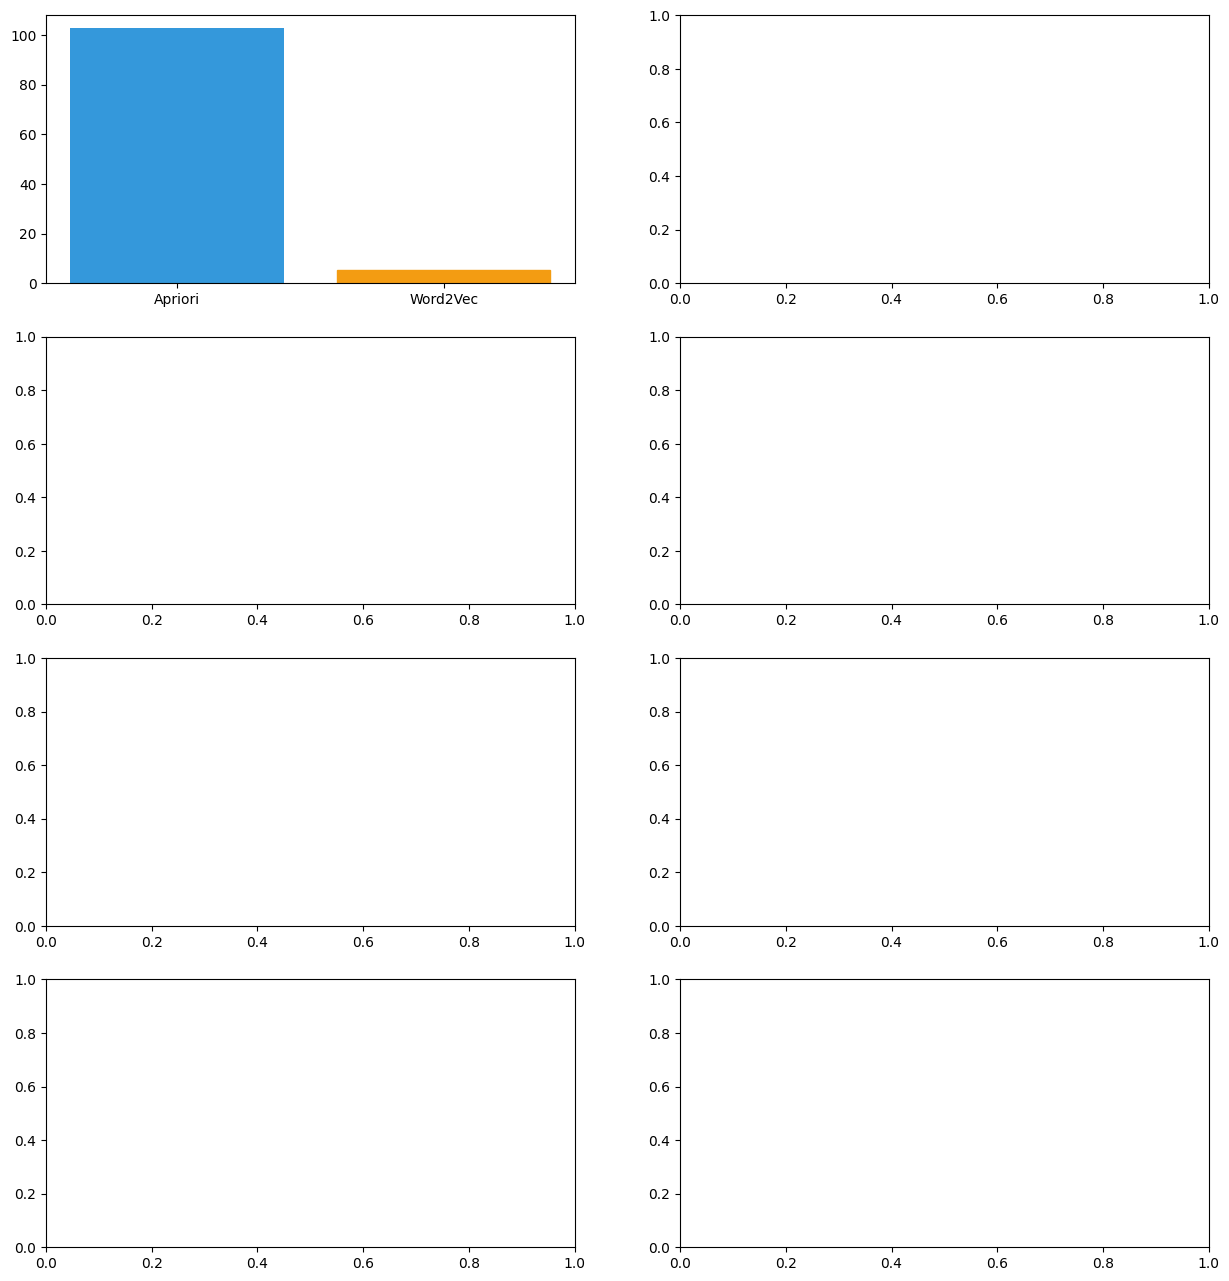

In [8]:
# Compare models with comprehensive analysis
comparison = evaluator.compare_models(
    include_validation=True,
    include_cold_start=True,
    include_clustering=True
)

# Display comparison table
print(comparison)

# Create visualizations
evaluator.visualize_comparison(
    save_path=os.path.join(path, 'model_comparison.png'),
    include_ci=True,
    include_validation=True
)

##  Save all results

In [ ]:
# Save all analysis results to output directory
evaluator.save_results(output_dir=os.path.join(path, 'model_comparison_results'))